In [58]:
import numpy as np
import pandas as pd
import scipy
import matplotlib.pyplot as plt
from scipy.io import loadmat
import torch

In [24]:
#subject = ('P300_data')

In [25]:
#data = loadmat(subject + '/S1901-P300_classic')
data = loadmat('C:/Users/torho/P300_Transformer/data_kirasirova/'+'S1901-P300_classic')

In [28]:
import mne

# Исходные данные
X = data['epochs']              # (6769, 3, 250)
y = data['labels'].ravel()      # (6769,)
y_names = data['labels_legend'] # ['0 - non-target; 1 - target']

# Создаём info — описание каналов.
# Для примера:
ch_names = ['Fz', 'Cz', 'Pz']            # названия каналов
sfreq = 250                              # если знаете частоту дискретизации
#The sampling rate was set to 250 Hz - из статьи

info = mne.create_info(ch_names, sfreq, ch_types='eeg')

# Формируем events — таблицу событий
events = np.column_stack((np.arange(len(y)), np.zeros(len(y), int), y))

# Словарь event_id из легенды:
event_id = {'non-target': 0, 'target': 1}

# Создаём объект Epochs
#Array
epochs = mne.EpochsArray(X, info, events=events, event_id=event_id)

# Проверим результат
print(epochs)


#в моем варианте - Загружается сырой .mat файл
#здесь - с MNE

Not setting metadata
6759 matching events found
No baseline correction applied
0 projection items activated
<EpochsArray | 6759 events (all good), 0 – 0.996 s (baseline off), ~38.7 MiB, data loaded,
 'non-target': 6344
 'target': 415>


In [29]:
epochs.ch_names

['Fz', 'Cz', 'Pz']

In [34]:
epochs.filter(l_freq=1, h_freq=15)

Setting up band-pass filter from 1 - 15 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 15.00 Hz
- Upper transition bandwidth: 3.75 Hz (-6 dB cutoff frequency: 16.88 Hz)
- Filter length: 825 samples (3.300 s)



C:\Users\torho\AppData\Local\Temp\ipykernel_26204\2778000940.py:1: RuntimeWarning: filter_length (825) is longer than the signal (250), distortion is likely. Reduce filter length or filter a longer signal.
  epochs.filter(l_freq=1, h_freq=15)


<EpochsArray | 6759 events (all good), 0 – 0.996 s (baseline off), ~38.7 MiB, data loaded,
 'non-target': 6344
 'target': 415>

In [35]:
all_non_target = epochs['non-target']
all_target = epochs['target']

In [36]:
def build_sequences(all_target, all_non_target, n_classes=16, n_samples=2000):
    X = []
    y = []

    targets = np.array(all_target._data)
    non_targets = np.array(all_non_target._data)
    T = targets.shape[2]

    for _ in range(n_samples):
        class_id = np.random.randint(n_classes)

        t = targets[np.random.randint(len(targets))]

        nts = non_targets[np.random.randint(len(non_targets), size=n_classes - 1)]

        seq = []
        nt_i = 0
        for pos in range(n_classes):
            if pos == class_id:
                seq.append(t)
            else:
                seq.append(nts[nt_i])
                nt_i += 1

        seq = np.concatenate(seq, axis=1)

        X.append(seq)
        y.append(class_id)

    return np.array(X), np.array(y)



In [37]:

X, y = build_sequences(all_target, all_non_target, n_classes=16, n_samples=2000)

print(X.shape)
print(y.shape)
print(np.unique(y))


(2000, 3, 4000)
(2000,)
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]


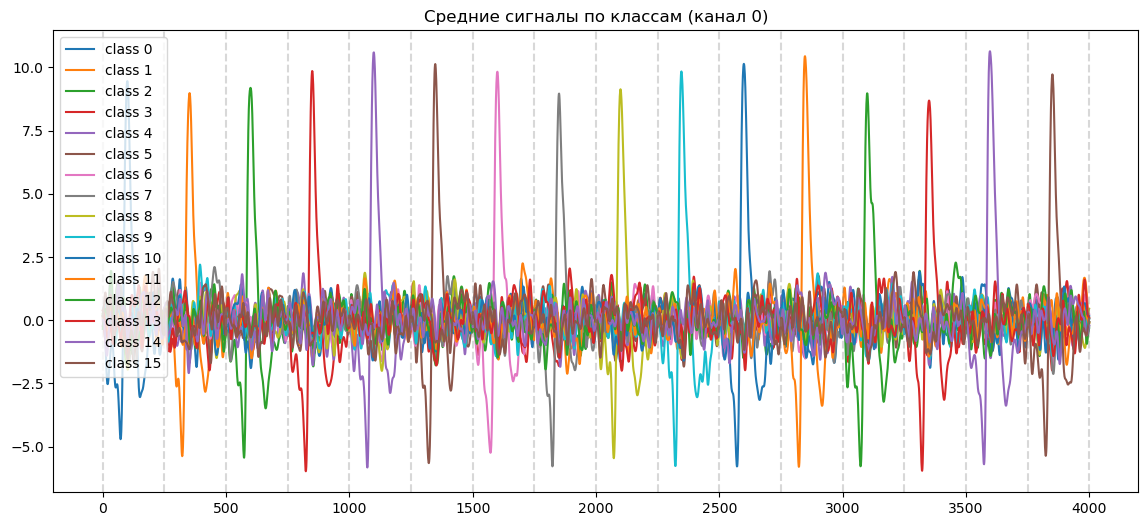

In [38]:

def plot_average_per_class(X, y, n_classes=16):
    T = X.shape[2] // n_classes
    plt.figure(figsize=(14, 6))

    for cls in range(n_classes):
        avg = X[y == cls].mean(axis=0)[0]
        plt.plot(avg, label=f"class {cls}")

    for i in range(17):
        plt.axvline(i * T, color='gray', linestyle='--', alpha=0.3)

    plt.title("Средние сигналы по классам (канал 0)")
    plt.legend()
    plt.show()

plot_average_per_class(X, y)




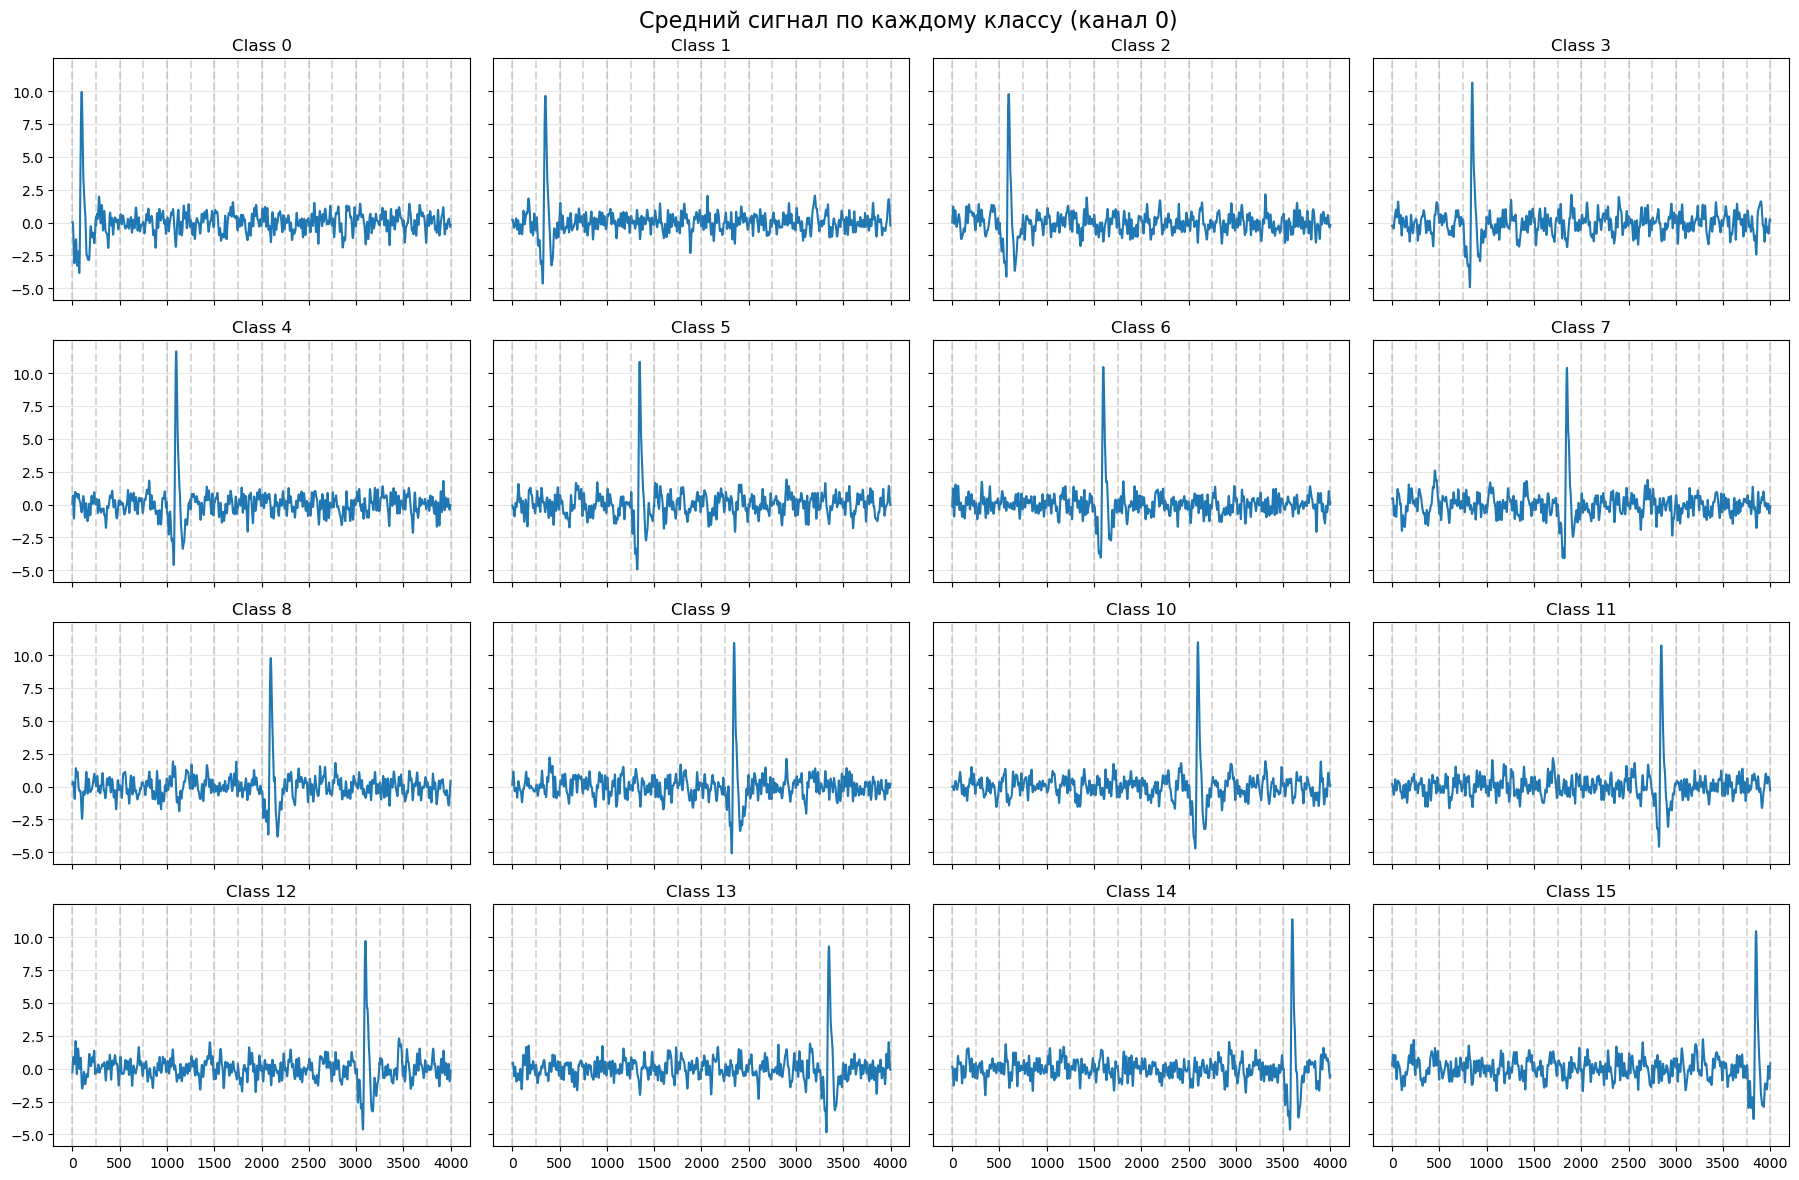

In [39]:

import matplotlib.pyplot as plt
import numpy as np

def plot_average_per_class_separate(X, y, n_classes=16, channel=2):
    T = X.shape[2] // n_classes

    fig, axes = plt.subplots(4, 4, figsize=(18, 12), sharex=True, sharey=True)
    axes = axes.flatten()

    for cls in range(n_classes):
        ax = axes[cls]
        avg = X[y == cls].mean(axis=0)[channel]

        ax.plot(avg, color='tab:blue')
        ax.set_title(f"Class {cls}")

        for i in range(n_classes + 1):
            ax.axvline(i * T, color='gray', linestyle='--', alpha=0.3)

        ax.grid(alpha=0.3)

    plt.suptitle("Средний сигнал по каждому классу (канал 0)", fontsize=16)
    plt.tight_layout()
    plt.savefig("average_per_class.png", dpi=300, bbox_inches="tight")
    plt.show()

plot_average_per_class_separate(X, y)

In [41]:

def build_averaged_dataset(X, y, K=10, repeats=10):
    X_avg = []
    y_avg = []

    classes = np.unique(y)

    for cls in classes:
        Xc = X[y == cls]

        for _ in range(repeats):
            idx = np.random.choice(len(Xc), K, replace=False)
            avg = Xc[idx].mean(axis=0)
            X_avg.append(avg)
            y_avg.append(cls)

    return np.stack(X_avg), np.array(y_avg)
